In [1]:
!pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.3 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12526 sha256=07094ade1cbe1e05ec17990a004a382b12f4693112984bd35992eba10f5ab000
  Stored in directory: /root/.cache/pip/wheels/f6/6e/1a/710143d0e50e827ae5b60a47a6d43d715cf1c6e35881a05530
Successfully built transformers-stream-generator


In [2]:
import torch
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2")

/tmp/ipykernel_2035/1659195434.py:4: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer


In [3]:
clean_prompt = "The capital of France is"
corrupted_prompt = "The capital of Germany is"

clean_tokens = model.to_tokens(clean_prompt)
corrupted_tokens = model.to_tokens(corrupted_prompt)

clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

In [4]:
paris_token = model.to_single_token(" Paris")
berlin_token = model.to_single_token(" Berlin")

def get_logit_diff(logits):
    last_logits = logits[0, -1]
    return (last_logits[paris_token] - last_logits[berlin_token]).item()

print("Clean logit diff (should be positive, favors Paris):", get_logit_diff(clean_logits))
print("Corrupted logit diff (should be negative, favors Berlin):", get_logit_diff(corrupted_logits))

Clean logit diff (should be positive, favors Paris): 1.8545589447021484
Corrupted logit diff (should be negative, favors Berlin): -3.2315330505371094


In [5]:
from transformer_lens import utils

def patch_residual_hook(corrupted_resid, hook, clean_cache):
    corrupted_resid[:, -1, :] = clean_cache[hook.name][:, -1, :]
    return corrupted_resid

patch_effects = []
for layer in range(model.cfg.n_layers):
    hook_name = utils.get_act_name("resid_post", layer)
    patched_logits = model.run_with_hooks(
        corrupted_tokens,
        fwd_hooks=[(hook_name, lambda act, hook: patch_residual_hook(act, hook, clean_cache))]
    )
    diff = get_logit_diff(patched_logits)
    patch_effects.append(diff)
    print(f"Layer {layer}: logit diff after patching = {diff:.3f}")

/tmp/ipykernel_2035/3615833655.py:1: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens import utils


Layer 0: logit diff after patching = -3.239
Layer 1: logit diff after patching = -3.215
Layer 2: logit diff after patching = -3.195
Layer 3: logit diff after patching = -3.144
Layer 4: logit diff after patching = -3.085
Layer 5: logit diff after patching = -3.112
Layer 6: logit diff after patching = -3.005
Layer 7: logit diff after patching = -3.009
Layer 8: logit diff after patching = -2.523
Layer 9: logit diff after patching = 0.196
Layer 10: logit diff after patching = 0.838
Layer 11: logit diff after patching = 1.855


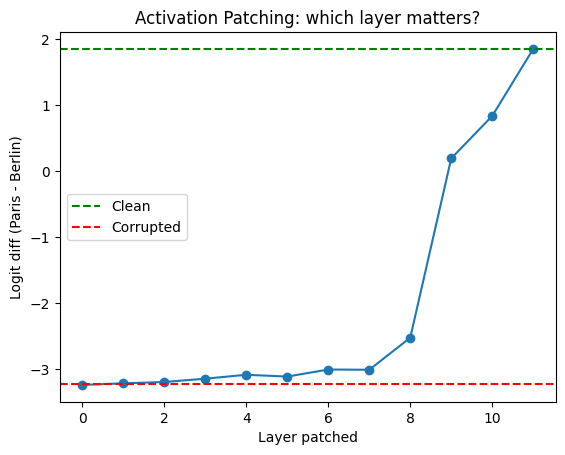

In [6]:
import matplotlib.pyplot as plt

plt.plot(patch_effects, marker='o')
plt.axhline(get_logit_diff(clean_logits), color='green', linestyle='--', label='Clean')
plt.axhline(get_logit_diff(corrupted_logits), color='red', linestyle='--', label='Corrupted')
plt.xlabel("Layer patched")
plt.ylabel("Logit diff (Paris - Berlin)")
plt.title("Activation Patching: which layer matters?")
plt.legend()
plt.show()